# Dataset Processing

## Загрузка

In [4]:
import kagglehub
from pathlib import Path

Path("./dataset/").mkdir(exist_ok=True)
kagglehub.dataset_download("weipengzhang/adobe-fivek", output_dir="./dataset", force_download=True)

100%|██████████| 26.5G/26.5G [19:59<00:00, 23.8MB/s]  

Extracting files...


'./dataset'

## Подбор параметров относительно результата эксперта

In [1]:
import json
import multiprocessing as mp
from functools import partial
from image_processing import process_image
from pathlib import Path
from random import shuffle
from time import time


def compute_dataset(
        type: str="statistic",
        dataset_path: str="./dataset",
        expert: str="c",
        result_path: str | None=None,
        output_dir: str | None=None,
        target_size: tuple[int, int] | None=None,
        max_iter: int=None,
        do_shaffle: bool=False,
        n_workers: int=-1,
        verbose_order: int=-1
    ):
    if type not in ("statistic", "optimization"):
        raise ValueError("Computation type must be statistic or optimization.")
    
    dataset_path = Path(dataset_path)
    if not dataset_path.exists():
        raise Exception(f"There is no folder like {dataset_path}.")
    
    if not dataset_path.is_dir():
        raise Exception(f"{dataset_path} is not folder.")
    
    has_raw = has_expert = False
    for folder in dataset_path.iterdir():
        if folder.name == "raw":
            if not any(folder.iterdir()):
                raise Exception("Folder raw is empty.")
            has_raw = True
        elif folder.name == expert:
            if not any(folder.iterdir()):
                raise Exception(f"Folder {expert} is empty.")
            has_expert = True

    if not has_raw:
        raise Exception(f"There is no raw folder in {dataset_path}.")
    
    if not has_expert:
        raise Exception(f"There is no {expert} folder in {dataset_path}.")
    
    raw_paths = sorted(Path(f"{dataset_path}/raw").iterdir())
    if do_shaffle:
        shuffle(raw_paths)
    if max_iter is not None:
        raw_paths = raw_paths[:max_iter]
    
    verbose = False if verbose_order == -1 else True
    results: list[dict] = []
    if verbose:
        verbose_order_number = 10 ** verbose_order
        start = time()

    worker = partial(
        process_image,
        dataset_path=dataset_path,
        expert=expert,
        target_size=target_size,
        method_type=type,
    )

    n_workers = mp.cpu_count() if n_workers == -1 else n_workers
    with mp.Pool(processes=n_workers) as pool:
        for i, res in enumerate(pool.imap(worker, raw_paths, chunksize=1)):
            if "error" in res:
                print(res["error"])
                continue

            results.append(res)

            if verbose and (i + 1) % verbose_order_number == 0:
                time_delta = time() - start
                if time_delta > 60:
                    print(f"{i+1} images; {time_delta // 60:.0f} min. {time_delta % 60:.0f} sec.")
                else:
                    print(f"{i+1} images; {time_delta:.0f} sec.")

    if result_path is None:
        result_path = f"{type}_method.json"
    if not result_path.endswith(".json"):
        result_path += ".json"
    
    if output_dir is not None:
        Path(output_dir).mkdir(exist_ok=True)
        result_path = f"{output_dir}/{result_path}"

    with open(result_path, "w") as result_file:
        json.dump(results, result_file, indent=2)

In [ ]:
compute_dataset(type="optimization", result_path="optimization.json", output_dir="./artefacts", max_iter=10, n_workers=10, verbose_order=0)

1 images; 87 min. 13 sec.
2 images; 177 min. 8 sec.
3 images; 177 min. 8 sec.
4 images; 178 min. 28 sec.
5 images; 197 min. 5 sec.
6 images; 205 min. 47 sec.
7 images; 205 min. 47 sec.
8 images; 205 min. 47 sec.
9 images; 205 min. 47 sec.
10 images; 205 min. 47 sec.


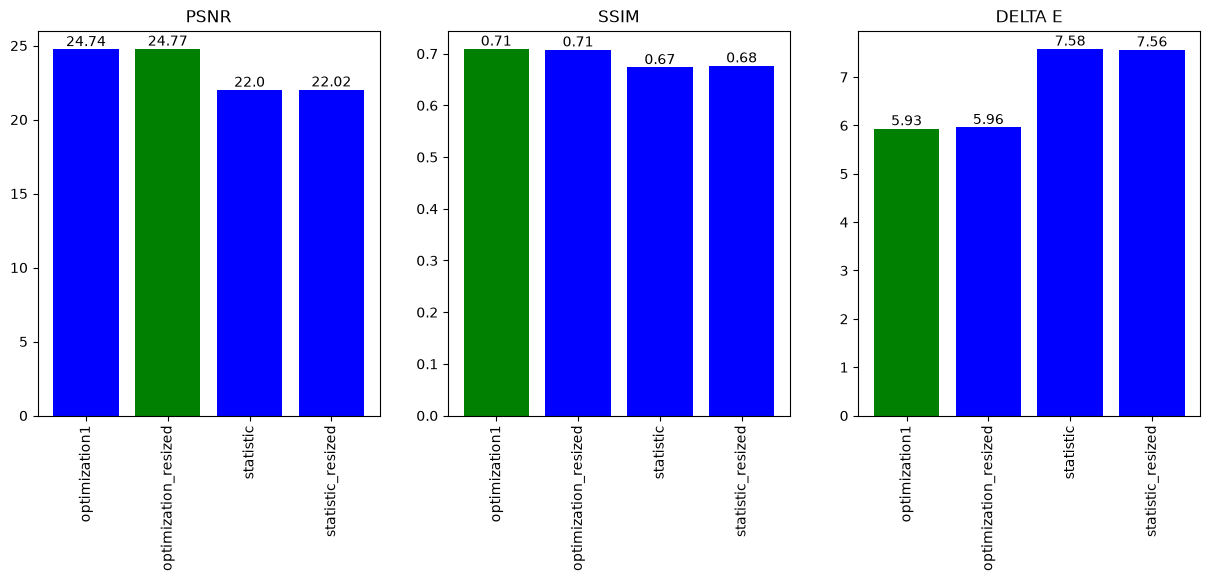

In [ ]:
import json
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path


names = []
psnr_mean = []
ssim_mean = []
delta_e_mean = []
metrics_names = ["psnr", "ssim", "delta e"]
metrics = [psnr_mean, ssim_mean, delta_e_mean]
files = [file for file in Path("./artefacts").glob("*.json") if len(file.name.split("_")) != 3]
for file_path in files:
    with open(file_path, "r") as file:
        data = json.load(file)
    
    psnr = []
    ssim = []
    delta_e = []
    for obj in data:
        psnr.append(obj["psnr"])
        ssim.append(obj["ssim"])
        delta_e.append(obj["delta_e"])
    
    names.append(file_path.name[:-5])
    psnr_mean.append(sum(psnr) / len(psnr))
    ssim_mean.append(sum(ssim) / len(ssim))
    delta_e_mean.append(sum(delta_e) / len(delta_e))


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axes = axes.flatten()

for i in range(3):
    colors = ["blue"] * len(names)
    best_value = np.argmax(metrics[i]) if metrics_names[i] != "delta e" else np.argmin(metrics[i])
    colors[best_value] = "green"
    container = axes[i].bar(names,  metrics[i], color=colors)
    axes[i].bar_label(container, map(lambda x: round(x, 2), metrics[i]))
    axes[i].set_title(metrics_names[i].upper())
    axes[i].set_xticks(names, names, rotation=90)

**Оптимизационный метод показал лучший результат относительно статического, а различия между полноразмерными и сжатыми изображениями оказались незначительными, так что последующий подбор параметров будет производиться на сжатых изображениях с помощью оптимизационного метода.**

In [ ]:
from CSRNet import INPUT_SIZE


compute_dataset(type="optimization", result_path="optimization_resized_full.json", output_dir="./artefacts", target_size=(INPUT_SIZE,INPUT_SIZE), n_workers=10, verbose_order=2)

100 images; 6 min. 45 sec.
200 images; 13 min. 42 sec.
300 images; 20 min. 33 sec.
400 images; 27 min. 58 sec.
500 images; 34 min. 31 sec.
600 images; 42 min. 2 sec.
700 images; 48 min. 52 sec.
800 images; 55 min. 51 sec.
900 images; 63 min. 23 sec.
1000 images; 71 min. 22 sec.
1100 images; 78 min. 11 sec.
1200 images; 86 min. 5 sec.
1300 images; 93 min. 58 sec.
1400 images; 101 min. 22 sec.
1500 images; 107 min. 59 sec.
1600 images; 114 min. 36 sec.
1700 images; 121 min. 50 sec.
1800 images; 128 min. 32 sec.
1900 images; 135 min. 4 sec.
2000 images; 141 min. 54 sec.
2100 images; 149 min. 3 sec.
2200 images; 155 min. 30 sec.
2300 images; 163 min. 3 sec.
2400 images; 170 min. 14 sec.
2500 images; 177 min. 18 sec.
2600 images; 184 min. 28 sec.
2700 images; 191 min. 46 sec.
2800 images; 198 min. 48 sec.
2900 images; 206 min. 7 sec.
3000 images; 214 min. 47 sec.
3100 images; 220 min. 53 sec.
3200 images; 227 min. 47 sec.
3300 images; 235 min. 25 sec.
3400 images; 242 min. 40 sec.
3500 imag

## Отображение подобранных параметров

In [6]:
import cv2
import json
import matplotlib.pyplot as plt
from image_processing import load_pair, apply_params
from pathlib import Path
from random import shuffle


def show_real_and_reconstructed_images(parameters_file: str, n: int=5, ssim_more_70: bool=False, do_shuffle: bool=False):
    if not Path(parameters_file).exists():
        raise FileNotFoundError(f"There is no {parameters_file} file.")
    if not parameters_file.endswith(".json"):
        raise Exception(f"{parameters_file} is not a json file.")
    
    with open(parameters_file, "r") as file:
        data = json.load(file)

    if do_shuffle:
        shuffle(data)

    if ssim_more_70:
        data = [obj for obj in data if obj["ssim"] > 0.7]
        
    data = data[:n]

    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(10, 3 * n))
    axes = axes.flatten()
    for i, obj in enumerate(data):
        raw_image_path = obj["raw_image"]
        expert_image_path = obj["expert_image"]
        brightness = obj["brightness"]
        contrast = obj["contrast"]
        saturation = obj["saturation"]

        raw_image, expert_image = load_pair(raw_image_path, expert_image_path)
        reconstructed_image = apply_params(raw_image, brightness, contrast, saturation)

        raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
        reconstructed_image = cv2.cvtColor(reconstructed_image, cv2.COLOR_BGR2RGB)
        expert_image = cv2.cvtColor(expert_image, cv2.COLOR_BGR2RGB)

        axes[i * 3].imshow(raw_image)
        axes[i * 3 + 1].imshow(reconstructed_image)
        axes[i * 3 + 2].imshow(expert_image)

        axes[i * 3].axis("off")
        axes[i * 3 + 1].axis("off")
        axes[i * 3 + 2].axis("off")

        axes[i * 3].set_title("original")
        axes[i * 3 + 1].set_title("reconstucted")
        axes[i * 3 + 2].set_title("expert")

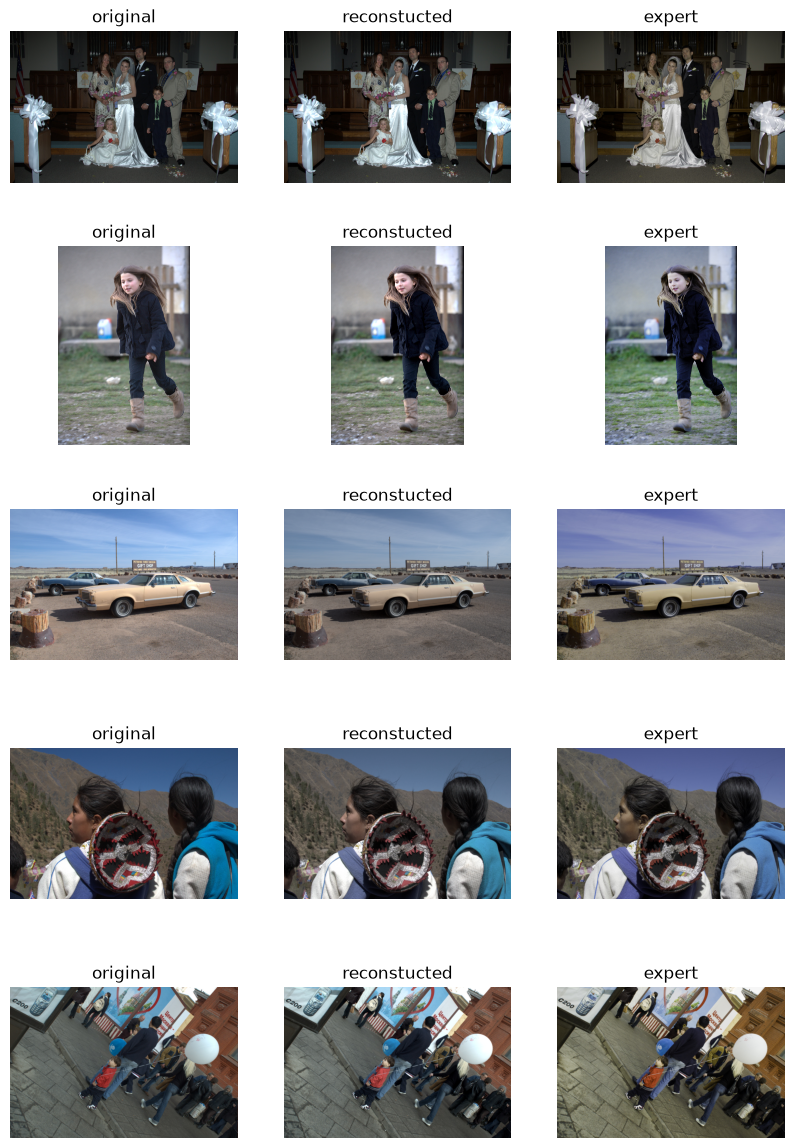

In [ ]:
show_real_and_reconstructed_images("./artefacts/optimization_resized_full.json", do_shuffle=True)

**Параметры подобрались не совсем точно, поэтому для обучения модели будет синтетически сгенерирован датасет из ухудшенных изображений экспертов на основе распределения параметров, полученных с помощью метода оптимизации**

## Создание датасета

In [ ]:
import json
import numpy as np


def check_value(value, min_value, max_value):
    return min_value <= value <= max_value


with open("./artefacts/optimization_resized_full.json", "r") as file:
    data = json.load(file)

expert_image_paths = []
brightness_values = []
contrast_values = []
saturation_values = []
for obj in data:
    expert_image_paths.append(obj["expert_image"])
    brightness_values.append(obj["brightness"])
    contrast_values.append(obj["contrast"])
    saturation_values.append(obj["saturation"])

for quant in [(0.02, 0.98), (0.05, 0.95)]:
    brightness_min, brightness_max = np.quantile(brightness_values, quant)
    contrast_min, contrast_max = np.quantile(contrast_values, quant)
    saturation_min, saturation_max = np.quantile(saturation_values, quant)

    params = [
        (brightness, contrast, saturation) for (brightness, contrast, saturation) in zip(brightness_values, contrast_values, saturation_values)
        if check_value(brightness, brightness_min, brightness_max) and check_value(contrast, contrast_min, contrast_max) and check_value(saturation, saturation_min, saturation_max)
    ]

    print(f"quantile: {quant}: осталось {len(params) / len(brightness_values) * 100:.2f}% значений")

quantile: (0.02, 0.98): осталось 89.80% значений
quantile: (0.05, 0.95): осталось 75.28% значений


**Чтобы исключить выбросы и при этом не потерять много данных будут использоваться значения с 2-го по 98-ой персентили**

In [ ]:
import json
import numpy as np
from multiprocessing import Pool
from functools import partial
from image_processing import downgrade_and_save_image
from pathlib import Path
from time import time


def check_value(value, min_value, max_value):
    return min_value <= value <= max_value


def generate_dataset(
        params_file: str,
        output_dir: str,
        output_file: str,
        quantile_range: tuple[float, float],
        image_target_size: tuple[int, int] | None=None,
        use_bootstrap: bool=False,
        max_iter: int=None,
        n_workers: int=-1,
        verbose_order: int=-1
    ):
    
    if not Path(params_file).exists():
        raise FileNotFoundError()
    
    if not params_file.endswith(".json"):
        raise Exception(f"{params_file} is not a .json file.")
    
    if not output_file.endswith(".json"):
        raise Exception(f"{output_file} is not a .josn file.")
    
    Path(output_dir).mkdir(exist_ok=True)

    with open(params_file, "r") as file:
        data = json.load(file)
    
    expert_image_paths = []
    brightness_values = []
    contrast_values = []
    saturation_values = []
    for obj in data:
        expert_image_paths.append(obj["expert_image"])
        brightness_values.append(obj["brightness"])
        contrast_values.append(obj["contrast"])
        saturation_values.append(obj["saturation"])
    
    if max_iter:
        expert_image_paths = expert_image_paths[:max_iter]

    brightness_min, brightness_max = np.quantile(brightness_values, quantile_range)
    contrast_min, contrast_max = np.quantile(contrast_values, quantile_range)
    saturation_min, saturation_max = np.quantile(saturation_values, quantile_range)

    if use_bootstrap:
        image_params = [
            (brightness, contrast, saturation) for (brightness, contrast, saturation) in zip(brightness_values, contrast_values, saturation_values)
            if check_value(brightness, brightness_min, brightness_max) and check_value(contrast, contrast_min, contrast_max) and check_value(saturation, saturation_min, saturation_max)
        ]
    else:
        image_params = None

    results: list[dict] = []
    max_retries = 1000
    verbose = False if verbose_order == -1 else True
    if verbose:
        verbose_order_number = 10 ** verbose_order
        start = time()

    worker = partial(
        downgrade_and_save_image,
        output_dir=output_dir,
        brightness_range=(brightness_min, brightness_max),
        contrast_range=(contrast_min, contrast_max),
        saturation_range=(saturation_min, saturation_max),
        image_params=image_params,
        image_target_size=image_target_size,
        max_retries=max_retries
    )
    n_workers = mp.cpu_count() if n_workers == -1 else n_workers
    with Pool(processes=n_workers) as pool:
        for i, res in enumerate(pool.imap(worker, expert_image_paths, chunksize=1)):
            if "error" in res:
                print(res["error"])
                continue
                
            results.append(res)
            
            if verbose and (i + 1) % verbose_order_number == 0:
                time_delta = time() - start
                if time_delta > 60:
                    print(f"{i+1} images; {time_delta // 60:.0f} min. {time_delta % 60:.0f} sec.")
                else:
                    print(f"{i+1} images; {time_delta:.0f} sec.")

    with open(output_file, "w") as file:
        json.dump(results, file, indent=2)

**Сравним 2 способа выбора случайных парметров: случайный из диапазона распределения значений и bootstrap троек значений**

In [ ]:
from CSRNet import INPUT_SIZE


generate_dataset(
    "./artefacts/optimization_resized_full.json",
    "dataset/optimization_synthetic_bootstrap",
    "./artefacts/optimization_dataset_bootstap.json",
    quantile_range=(0.02, 0.98),
    image_target_size=(INPUT_SIZE, INPUT_SIZE),
    use_bootstrap=True,
    n_workers=8,
    verbose_order=2
)

100 images; 44 sec.
200 images; 54 sec.
300 images; 1 min. 18 sec.
400 images; 1 min. 38 sec.
500 images; 2 min. 4 sec.
600 images; 2 min. 26 sec.
700 images; 2 min. 46 sec.
800 images; 3 min. 9 sec.
900 images; 4 min. 7 sec.
1000 images; 4 min. 8 sec.
1100 images; 4 min. 32 sec.
1200 images; 5 min. 7 sec.
1300 images; 5 min. 25 sec.
1400 images; 6 min. 9 sec.
1500 images; 6 min. 39 sec.
1600 images; 6 min. 49 sec.
1700 images; 7 min. 23 sec.
1800 images; 7 min. 40 sec.
1900 images; 8 min. 7 sec.
2000 images; 8 min. 33 sec.
2100 images; 9 min. 3 sec.
2200 images; 9 min. 25 sec.
2300 images; 9 min. 51 sec.
2400 images; 10 min. 20 sec.
2500 images; 10 min. 40 sec.
2600 images; 11 min. 8 sec.
2700 images; 11 min. 32 sec.
2800 images; 12 min. 4 sec.
2900 images; 12 min. 31 sec.
3000 images; 12 min. 54 sec.
3100 images; 13 min. 20 sec.
3200 images; 13 min. 38 sec.
3300 images; 14 min. 14 sec.
3400 images; 14 min. 35 sec.
3500 images; 14 min. 55 sec.
3600 images; 15 min. 18 sec.
3700 images;

In [ ]:
from CSRNet import INPUT_SIZE


generate_dataset(
    "./artefacts/optimization_resized_full.json",
    "dataset/optimization_synthetic",
    "./artefacts/optimization_dataset.json",
    quantile_range=(0.02, 0.98),
    image_target_size=(INPUT_SIZE, INPUT_SIZE),
    n_workers=8,
    verbose_order=2
)

100 images; 24 sec.
200 images; 46 sec.
300 images; 1 min. 6 sec.
400 images; 1 min. 27 sec.
500 images; 1 min. 46 sec.
600 images; 2 min. 5 sec.
700 images; 2 min. 28 sec.
800 images; 2 min. 46 sec.
900 images; 3 min. 8 sec.
1000 images; 3 min. 29 sec.
1100 images; 3 min. 51 sec.
1200 images; 4 min. 13 sec.
1300 images; 4 min. 37 sec.
1400 images; 4 min. 58 sec.
1500 images; 5 min. 19 sec.
1600 images; 5 min. 41 sec.
1700 images; 6 min. 1 sec.
1800 images; 6 min. 22 sec.
1900 images; 6 min. 43 sec.
2000 images; 7 min. 6 sec.
2100 images; 7 min. 26 sec.
2200 images; 7 min. 46 sec.
2300 images; 8 min. 8 sec.
2400 images; 8 min. 30 sec.
2500 images; 8 min. 51 sec.
2600 images; 9 min. 12 sec.
2700 images; 9 min. 32 sec.
2800 images; 9 min. 53 sec.
2900 images; 10 min. 14 sec.
3000 images; 10 min. 37 sec.
3100 images; 10 min. 57 sec.
3200 images; 11 min. 18 sec.
3300 images; 11 min. 40 sec.
3400 images; 12 min. 4 sec.
3500 images; 12 min. 24 sec.
3600 images; 12 min. 43 sec.
3700 images; 1